# European Ski Resorts — EDA & Preprocessing
**Phase 2 Capstone — Part 1**

Dataset: [European Ski Resorts (Kaggle)](https://www.kaggle.com/datasets/thomasnibb/european-ski-resorts) — 376 resorts, 16 features covering elevation, slopes, lifts, pricing, and amenities.

This notebook covers:
1. **Initial EDA** — distributions, relationships, data quality issues
2. **Data wrangling & preprocessing** — cleaning, missing-value handling, categorical encoding, scaling

Outputs (for modeling in later parts):
- `ski_resorts_clean.csv` — cleaned, human-readable dataset (for Tableau / EDA)
- `ski_resorts_processed.csv` — encoded + scaled feature matrix (for supervised & unsupervised modeling)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = 'data/European_Ski_Resorts.csv'
df = pd.read_csv(DATA_PATH, index_col=0)
print(df.shape)
df.head()

(376, 17)


,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons
1,Alpendorf (Ski amedé),Austria,1980,740,52,30,81,4,115,Yes,No,22,16,11,49,75398,600
2,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47,100,77,33,210,Yes,Yes,37,28,7,72,99017,1032
3,Oberau (Wildschönau),Austria,1130,900,30,1,0,1,2,No,No,2,0,0,2,1932,0
4,Dachstein West,Austria,1620,780,42,15,33,3,51,Yes,Yes,25,8,3,36,32938,163
5,Rosa Khutor,Southern Russia,2320,940,22,30,26,21,77,Yes,No,6,11,10,27,49228,450


## 1. Initial EDA

### 1.1 Structure & summary statistics

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 376 entries, 1 to 376
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Resort             376 non-null    str  
 1   Country            376 non-null    str  
 2   HighestPoint       376 non-null    int64
 3   LowestPoint        376 non-null    int64
 4   DayPassPriceAdult  376 non-null    int64
 5   BeginnerSlope      376 non-null    int64
 6   IntermediateSlope  376 non-null    int64
 7   DifficultSlope     376 non-null    int64
 8   TotalSlope         376 non-null    int64
 9   Snowparks          376 non-null    str  
 10  NightSki           376 non-null    str  
 11  SurfaceLifts       376 non-null    int64
 12  ChairLifts         376 non-null    int64
 13  GondolaLifts       376 non-null    int64
 14  TotalLifts         376 non-null    int64
 15  LiftCapacity       376 non-null    int64
 16  SnowCannons        376 non-null    int64
dtypes: int64(13), str(4)
memory

In [8]:
df.describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
HighestPoint,376.0,2051.7,776.7,0.0,1550.0,2104.0,2567.5,3899.0
LowestPoint,376.0,1055.1,423.6,0.0,779.2,1050.0,1350.0,2180.0
DayPassPriceAdult,376.0,40.8,12.5,0.0,34.0,42.0,49.0,81.0
BeginnerSlope,376.0,35.9,53.7,0.0,8.0,19.0,40.0,312.0
IntermediateSlope,376.0,38.3,49.7,0.0,9.0,22.0,42.2,239.0
DifficultSlope,376.0,11.8,17.8,0.0,2.0,5.0,13.0,103.0
TotalSlope,376.0,86.3,113.7,0.0,25.0,48.0,100.0,600.0
SurfaceLifts,376.0,13.7,14.4,0.0,5.0,9.0,17.0,89.0
ChairLifts,376.0,9.3,12.6,0.0,2.0,5.0,10.0,74.0
GondolaLifts,376.0,4.0,6.6,0.0,0.0,2.0,5.0,40.0


**First observations**
- 376 rows × 16 columns; 13 numeric, 3 text (`Resort`, `Country`, plus the yes/no columns `Snowparks` and `NightSki`).
- Several numeric columns have a **min of 0** where 0 is implausible (e.g., `DayPassPriceAdult`, `HighestPoint`) — zeros here are likely missing-value codes, not real values. Investigated below.
- Slope/lift features are heavily **right-skewed** (a few mega-resorts like Les 3 Vallées dominate).

### 1.2 Data quality checks

In [9]:
print('Explicit nulls per column:')
print(df.isna().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('Duplicate resort names:', df['Resort'].duplicated().sum())

Explicit nulls per column:
Resort               0
Country              0
HighestPoint         0
LowestPoint          0
DayPassPriceAdult    0
BeginnerSlope        0
IntermediateSlope    0
DifficultSlope       0
TotalSlope           0
Snowparks            0
NightSki             0
SurfaceLifts         0
ChairLifts           0
GondolaLifts         0
TotalLifts           0
LiftCapacity         0
SnowCannons          0
dtype: int64

Duplicate rows: 0
Duplicate resort names: 0


In [10]:
# Yes/No columns: Snowparks contains a third value, 'no report' (disguised missing)
for c in ['Snowparks', 'NightSki']:
    print(c, dict(df[c].value_counts()))

Snowparks {'Yes': np.int64(278), 'No': np.int64(90), 'no report': np.int64(8)}
NightSki {'No': np.int64(224), 'Yes': np.int64(152)}


In [11]:
# Zeros as disguised missing values / non-resorts
print('DayPassPriceAdult == 0 :', (df['DayPassPriceAdult'] == 0).sum())
print('TotalSlope == 0        :', (df['TotalSlope'] == 0).sum())
print('TotalLifts == 0        :', (df['TotalLifts'] == 0).sum())
print('HighestPoint == 0      :', (df['HighestPoint'] == 0).sum())

# Who are the zero-price rows?
df.loc[df['DayPassPriceAdult'] == 0, ['Resort', 'Country', 'TotalSlope', 'TotalLifts']]

DayPassPriceAdult == 0 : 8
TotalSlope == 0        : 11
TotalLifts == 0        : 8
HighestPoint == 0      : 1


,Resort,Country,TotalSlope,TotalLifts
124,Pragelato,Italy,50,5
132,Sheregesh-Kemerovo,Siberia,0,12
163,Alpika Service,Southern Russia,25,9
218,Indoor ski area Skidome Denmark – Randers (pla...,Denmark,3,0
219,Dry slopes Indoorski – Rødovre,Denmark,0,0
220,Dry slopes Ski Arena – Aarhus,Denmark,0,0
221,Copenhagen (planned),Denmark,0,0
256,Puigmal,France,32,13


Several of the zero-heavy rows are **not real operating ski resorts**: indoor ski domes, dry slopes, and resorts marked *(planned)* (e.g., `Copenhagen (planned)` is all zeros). These would distort any model of real resorts and are dropped in preprocessing. The remaining zero prices (real resorts like Pragelato) are treated as missing and imputed.

In [12]:
# Internal consistency checks
slope_sum = df[['BeginnerSlope', 'IntermediateSlope', 'DifficultSlope']].sum(axis=1)
lift_sum  = df[['SurfaceLifts', 'ChairLifts', 'GondolaLifts']].sum(axis=1)
print('Rows where slope categories != TotalSlope :', (slope_sum != df['TotalSlope']).sum())
print('Rows where lift types != TotalLifts       :', (lift_sum != df['TotalLifts']).sum())
print('Rows where HighestPoint <= LowestPoint    :', (df['HighestPoint'] <= df['LowestPoint']).sum())

Rows where slope categories != TotalSlope : 87
Rows where lift types != TotalLifts       : 0
Rows where HighestPoint <= LowestPoint    : 1


- **Lifts are internally consistent** (types always sum to `TotalLifts`).
- **87 rows** have slope categories that don't sum to `TotalSlope` — the source (skiresort.info) sometimes reports total km separately from the difficulty breakdown. We keep `TotalSlope` as the authoritative size measure.
- The single `HighestPoint <= LowestPoint` row is the all-zero planned Copenhagen resort, handled by the drop above.

### 1.3 Distributions

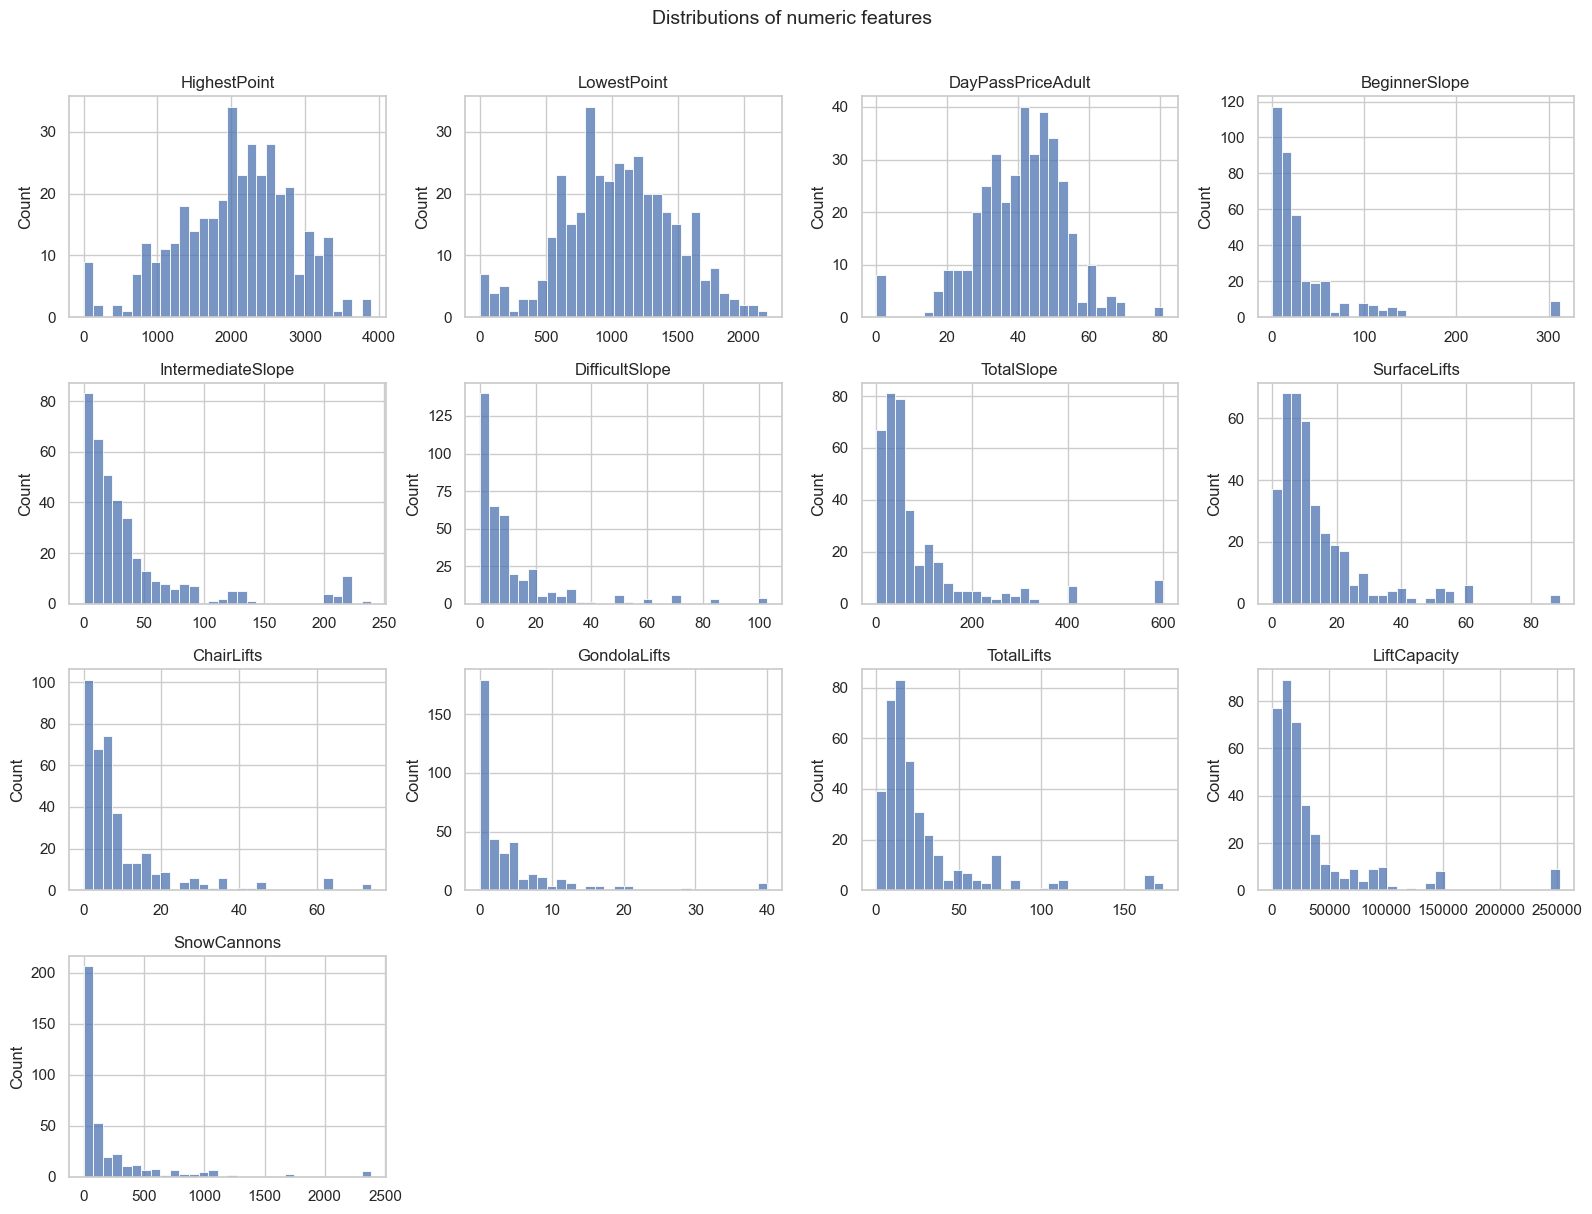

In [13]:
num_cols = df.select_dtypes('number').columns
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, c in zip(axes.flat, num_cols):
    sns.histplot(df[c], bins=30, ax=ax, color='#4c72b0')
    ax.set_title(c)
    ax.set_xlabel('')
for ax in axes.flat[len(num_cols):]:
    ax.axis('off')
plt.suptitle('Distributions of numeric features', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

Elevation features (`HighestPoint`, `LowestPoint`) are roughly bell-shaped; price is near-normal around €40; every size-related feature (slopes, lifts, capacity, snow cannons) is strongly right-skewed with a long tail of mega-resorts — a good argument for scaling before clustering, and worth remembering when interpreting means.

### 1.4 Countries

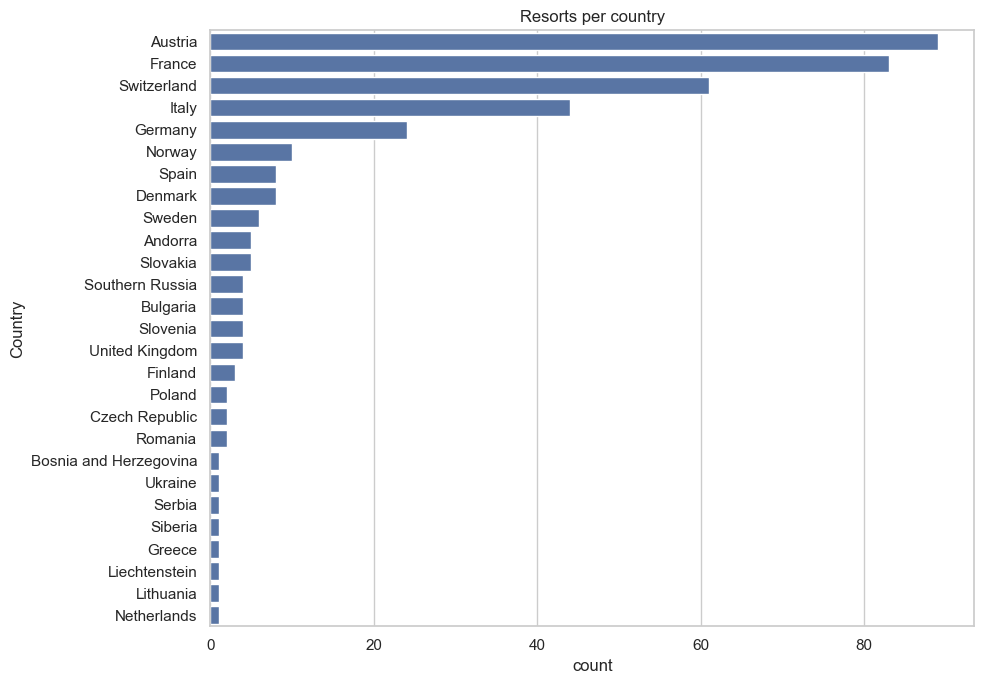

In [14]:
plt.figure(figsize=(10, 7))
order = df['Country'].value_counts().index
sns.countplot(y='Country', data=df, order=order, color='#4c72b0')
plt.title('Resorts per country')
plt.tight_layout()
plt.show()

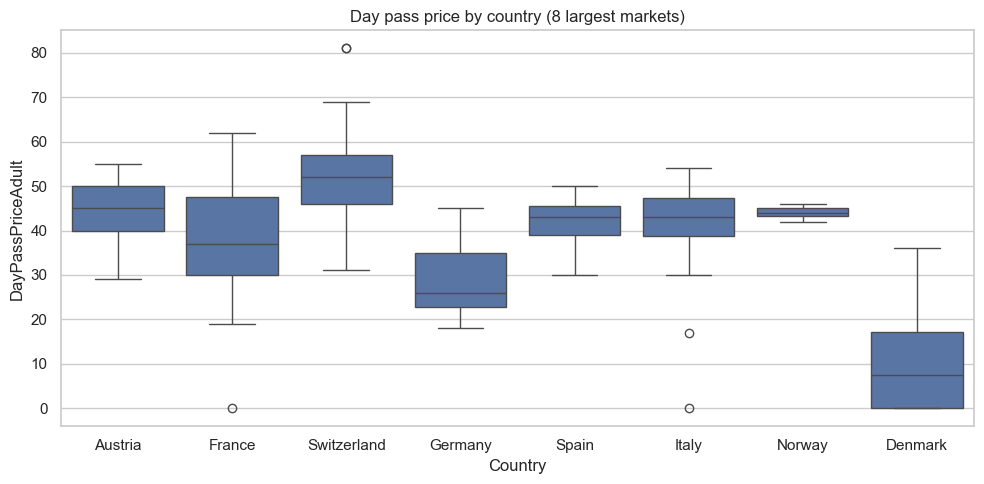

In [15]:
top = df['Country'].value_counts().head(8).index
plt.figure(figsize=(10, 5))
sns.boxplot(x='Country', y='DayPassPriceAdult', data=df[df['Country'].isin(top)], color='#4c72b0')
plt.title('Day pass price by country (8 largest markets)')
plt.tight_layout()
plt.show()

The Alps dominate: Austria, France, Switzerland, and Italy hold ~74% of resorts. Switzerland is clearly the most expensive market; Germany the cheapest of the big four. Many countries have <5 resorts — too sparse to one-hot encode individually (handled in preprocessing by grouping into `Other`).

### 1.5 Relationships

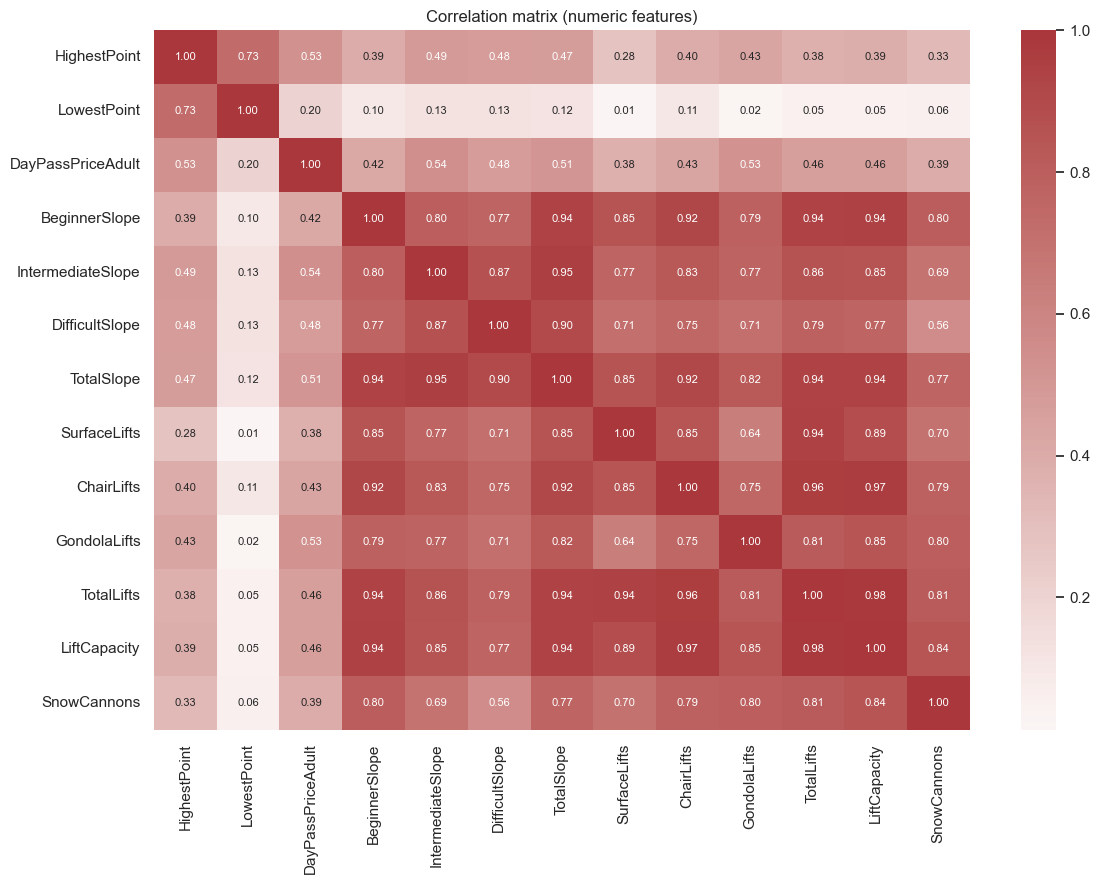

In [16]:
plt.figure(figsize=(12, 9))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='vlag', center=0,
            annot_kws={'size': 8})
plt.title('Correlation matrix (numeric features)')
plt.tight_layout()
plt.show()

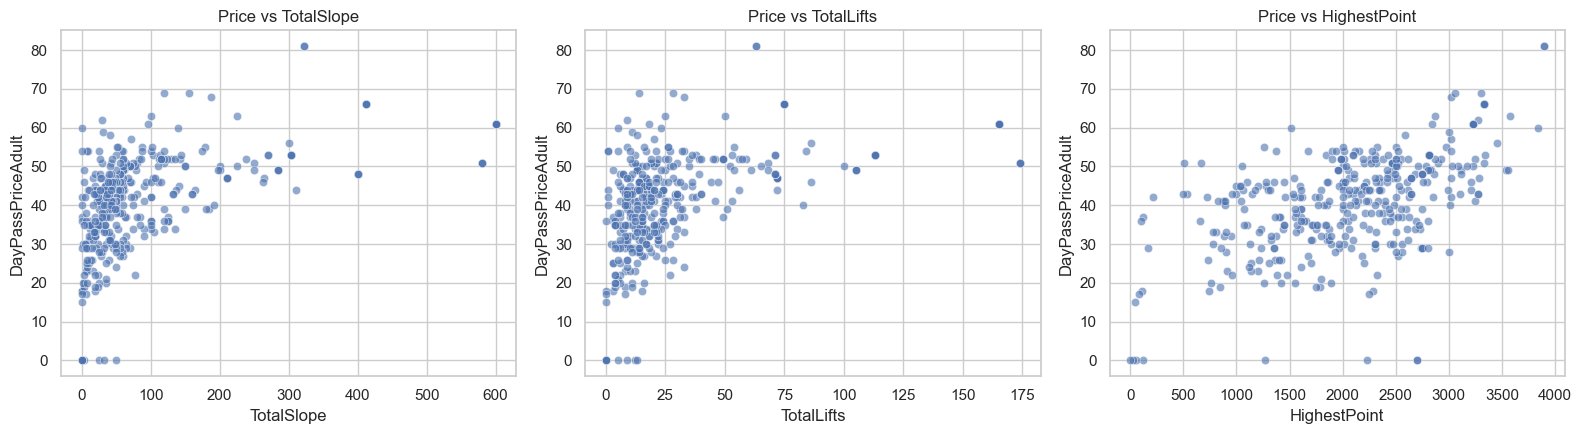

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, x in zip(axes, ['TotalSlope', 'TotalLifts', 'HighestPoint']):
    sns.scatterplot(x=x, y='DayPassPriceAdult', data=df, ax=ax, alpha=0.6)
    ax.set_title(f'Price vs {x}')
plt.tight_layout()
plt.show()

**Key relationships**
- Size features are highly inter-correlated (`TotalSlope` ↔ `TotalLifts` ↔ `LiftCapacity`, r ≈ 0.8–0.9) — multicollinearity to watch for in linear models; also motivates dimensionality reduction (PCA) or clustering on "resort size" in the unsupervised step.
- `DayPassPriceAdult` correlates moderately with resort size and elevation — a reasonable **regression target** for the supervised step.
- Elevation and size are only weakly related: big resorts exist at many altitudes.

## 2. Data Wrangling & Preprocessing

Plan, based on the EDA above:
1. Drop non-resorts (planned / indoor / dry-slope rows with no slopes **and** no lifts)
2. Treat `Snowparks = 'no report'` and `DayPassPriceAdult = 0` as missing; impute
3. Encode: yes/no → 1/0; group rare countries → one-hot
4. Feature-engineer `VerticalDrop`
5. Scale numeric features (StandardScaler) for the model-ready matrix

### 2.1 Remove non-resort rows

In [18]:
clean = df.copy()
non_resorts = clean[(clean['TotalSlope'] == 0) & (clean['TotalLifts'] == 0)]
print('Dropping', len(non_resorts), 'non-resort rows:')
print(non_resorts[['Resort', 'Country']].to_string())
clean = clean.drop(non_resorts.index).reset_index(drop=True)

# Sheregesh & Aarhus-style edge cases: rows still missing core size data (slope OR lifts == 0)
# are kept only if they have real activity; drop any that still have zero lifts (unusable)
clean = clean[clean['TotalLifts'] > 0].reset_index(drop=True)
print('\nRemaining rows:', len(clean))

Dropping 7 non-resort rows:
                                     Resort  Country
217  Dry slopes Dayz Søhøjlandets Skicenter  Denmark
219          Dry slopes Indoorski – Rødovre  Denmark
220           Dry slopes Ski Arena – Aarhus  Denmark
221                    Copenhagen (planned)  Denmark
222                    Østerlars (Bornholm)  Denmark
223                 Hoch Hylkedal – Kolding  Denmark
342                     Hedelands Skicenter  Denmark

Remaining rows: 368


### 2.2 Handle missing values

In [19]:
# 'no report' in Snowparks -> NaN -> impute with mode
clean['Snowparks'] = clean['Snowparks'].replace('no report', np.nan)
mode = clean['Snowparks'].mode()[0]
n_missing = clean['Snowparks'].isna().sum()
clean['Snowparks'] = clean['Snowparks'].fillna(mode)
print(f'Snowparks: imputed {n_missing} missing values with mode = {mode!r}')

# Price 0 -> NaN -> impute with country median (falls back to overall median)
clean['DayPassPriceAdult'] = clean['DayPassPriceAdult'].replace(0, np.nan)
n_missing = clean['DayPassPriceAdult'].isna().sum()
country_median = clean.groupby('Country')['DayPassPriceAdult'].transform('median')
clean['DayPassPriceAdult'] = (clean['DayPassPriceAdult']
                              .fillna(country_median)
                              .fillna(clean['DayPassPriceAdult'].median()))
print(f'DayPassPriceAdult: imputed {n_missing} zero-coded prices with country median')

assert clean.isna().sum().sum() == 0
print('\nNo missing values remain.')

Snowparks: imputed 0 missing values with mode = 'Yes'
DayPassPriceAdult: imputed 4 zero-coded prices with country median

No missing values remain.


### 2.3 Feature engineering & encoding

In [20]:
# Vertical drop = skiable elevation range
clean['VerticalDrop'] = clean['HighestPoint'] - clean['LowestPoint']

# Binary encode yes/no amenities
clean['Snowparks'] = clean['Snowparks'].map({'Yes': 1, 'No': 0})
clean['NightSki']  = clean['NightSki'].map({'Yes': 1, 'No': 0})

# Group countries with < 5 resorts into 'Other', then one-hot encode
counts = clean['Country'].value_counts()
clean['CountryGrouped'] = clean['Country'].where(clean['Country'].isin(counts[counts >= 5].index), 'Other')
print(clean['CountryGrouped'].value_counts())

country_dummies = pd.get_dummies(clean['CountryGrouped'], prefix='Country', dtype=int)
clean.head()

CountryGrouped
Austria        89
France         83
Switzerland    61
Italy          44
Other          33
Germany        24
Norway         10
Spain           8
Sweden          6
Andorra         5
Slovakia        5
Name: count, dtype: int64


,Resort,Country,HighestPoint,LowestPoint,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,Snowparks,NightSki,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,VerticalDrop,CountryGrouped
0,Alpendorf (Ski amedé),Austria,1980,740,52.0,30,81,4,115,1,0,22,16,11,49,75398,600,1240,Austria
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,Andorra,2640,1710,47.0,100,77,33,210,1,1,37,28,7,72,99017,1032,930,Andorra
2,Oberau (Wildschönau),Austria,1130,900,30.0,1,0,1,2,0,0,2,0,0,2,1932,0,230,Austria
3,Dachstein West,Austria,1620,780,42.0,15,33,3,51,1,1,25,8,3,36,32938,163,840,Austria
4,Rosa Khutor,Southern Russia,2320,940,22.0,30,26,21,77,1,0,6,11,10,27,49228,450,1380,Other


### 2.4 Scale numeric features → model-ready matrix

In [21]:
feature_cols = ['HighestPoint', 'LowestPoint', 'VerticalDrop', 'DayPassPriceAdult',
                'BeginnerSlope', 'IntermediateSlope', 'DifficultSlope', 'TotalSlope',
                'SurfaceLifts', 'ChairLifts', 'GondolaLifts', 'TotalLifts',
                'LiftCapacity', 'SnowCannons']

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(clean[feature_cols]),
                      columns=feature_cols, index=clean.index)

processed = pd.concat([clean[['Resort']], scaled,
                       clean[['Snowparks', 'NightSki']], country_dummies], axis=1)
print(processed.shape)
processed.head()

(368, 28)


,Resort,HighestPoint,LowestPoint,VerticalDrop,DayPassPriceAdult,BeginnerSlope,IntermediateSlope,DifficultSlope,TotalSlope,SurfaceLifts,ChairLifts,GondolaLifts,TotalLifts,LiftCapacity,SnowCannons,Snowparks,NightSki,Country_Andorra,Country_Austria,Country_France,Country_Germany,Country_Italy,Country_Norway,Country_Other,Country_Slovakia,Country_Spain,Country_Sweden,Country_Switzerland
0,Alpendorf (Ski amedé),-0.158187,-0.843805,0.413236,0.938457,-0.123165,0.839149,-0.449353,0.235537,0.557132,0.510879,1.054223,0.690495,0.865914,0.920464,1,0,0,1,0,0,0,0,0,0,0,0,0
1,Soldeu-Pas de la Casa/​Grau Roig/​El Tarter/​C...,0.750827,1.583072,-0.162748,0.477250,1.173947,0.758888,1.173488,1.068131,1.596459,1.460390,0.448281,1.430660,1.378174,1.975486,1,1,1,0,0,0,0,0,0,0,0,0,0
2,Oberau (Wildschönau),-1.328886,-0.443495,-1.463356,-1.090856,-0.660540,-0.786150,-0.617233,-0.754813,-0.828638,-0.755137,-0.612116,-0.822018,-0.727450,-0.544845,0,0,0,1,0,0,0,0,0,0,0,0,0
3,Dachstein West,-0.654012,-0.743727,-0.329969,0.016042,-0.401118,-0.123991,-0.505313,-0.325369,0.764998,-0.122129,-0.157660,0.272140,-0.054978,-0.146770,1,1,0,1,0,0,0,0,0,0,0,0,0
4,Rosa Khutor,0.310093,-0.343418,0.673358,-1.828789,-0.123165,-0.264449,0.501967,-0.097501,-0.551484,0.115249,0.902737,-0.017490,0.298327,0.554136,1,0,0,0,0,0,0,0,1,0,0,0,0


### 2.5 Save outputs

In [22]:
clean_out = clean.drop(columns=['CountryGrouped'])
clean_out.to_csv('ski_resorts_clean.csv', index=False)
processed.to_csv('ski_resorts_processed.csv', index=False)
print('Saved ski_resorts_clean.csv     ', clean_out.shape)
print('Saved ski_resorts_processed.csv ', processed.shape)

Saved ski_resorts_clean.csv      (368, 18)
Saved ski_resorts_processed.csv  (368, 28)


## Summary

**EDA findings**
- 376 resorts across 27 countries; Alps countries hold ~74%. No explicit nulls or duplicates, but missingness was disguised as zeros and `'no report'`.
- Size features (slopes, lifts, capacity) are right-skewed and highly inter-correlated; price is roughly normal around €40 and correlates with size and elevation.

**Preprocessing decisions**
- Dropped 7 planned/indoor/dry-slope rows that aren't operating resorts.
- Imputed `Snowparks` ('no report' → mode) and zero-coded prices (→ country median).
- Engineered `VerticalDrop`; binary-encoded amenities; grouped rare countries (<5 resorts) into `Other` before one-hot encoding; standardized all numeric features.

**Handoff to modeling**
- *Supervised:* regression on `DayPassPriceAdult` (unscale or re-derive target as needed), or classify price tiers.
- *Unsupervised:* K-Means / PCA on the scaled size + elevation features to segment resort types (e.g., mega-resorts vs. small local hills) — the heavy multicollinearity means PCA should compress these well.